# Notebook 05 — Reduced-Zone Fermi Surface, $V_0 = 0$

Geometric construction of the free-electron Fermi surface in the reduced-zone scheme. Sample the Fermi circle in the extended zone, classify each sample by which Brillouin zone it occupies, and translate by the appropriate reciprocal vector $\mathbf{G}$ to fold it back into BZ1.

- **Band 1**: the parts of the Fermi circle originally inside BZ1 — four arcs along the $\Gamma$–M diagonals.
- **Band 2**: the BZ2 portions of the circle folded by the appropriate $\mathbf{G}$. For the divalent square at $V_0=0$ these become four pockets centered on the X (wall-midpoint) points, split across the BZ1 walls.



In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from src.lattice import high_symmetry_points
from src.fermi import fold_fermi_circle_to_bz1

FIG_DIR = ROOT / "figures" / "05_reduced_zone"
FIG_DIR.mkdir(parents=True, exist_ok=True)

k_F = 2.0 * np.sqrt(np.pi)
band1_arcs, band2_arcs = fold_fermi_circle_to_bz1(k_F, n_samples=4000)

print(f"k_F = {k_F:.4f}")
print(f"band 1 arcs: count = {len(band1_arcs)}, sizes = {[a.shape[0] for a in band1_arcs]}")
print(f"band 2 arcs: count = {len(band2_arcs)}, sizes = {[a.shape[0] for a in band2_arcs]}")

k_F = 3.5449
band 1 arcs: count = 4, sizes = [387, 387, 387, 387]
band 2 arcs: count = 4, sizes = [613, 613, 613, 613]


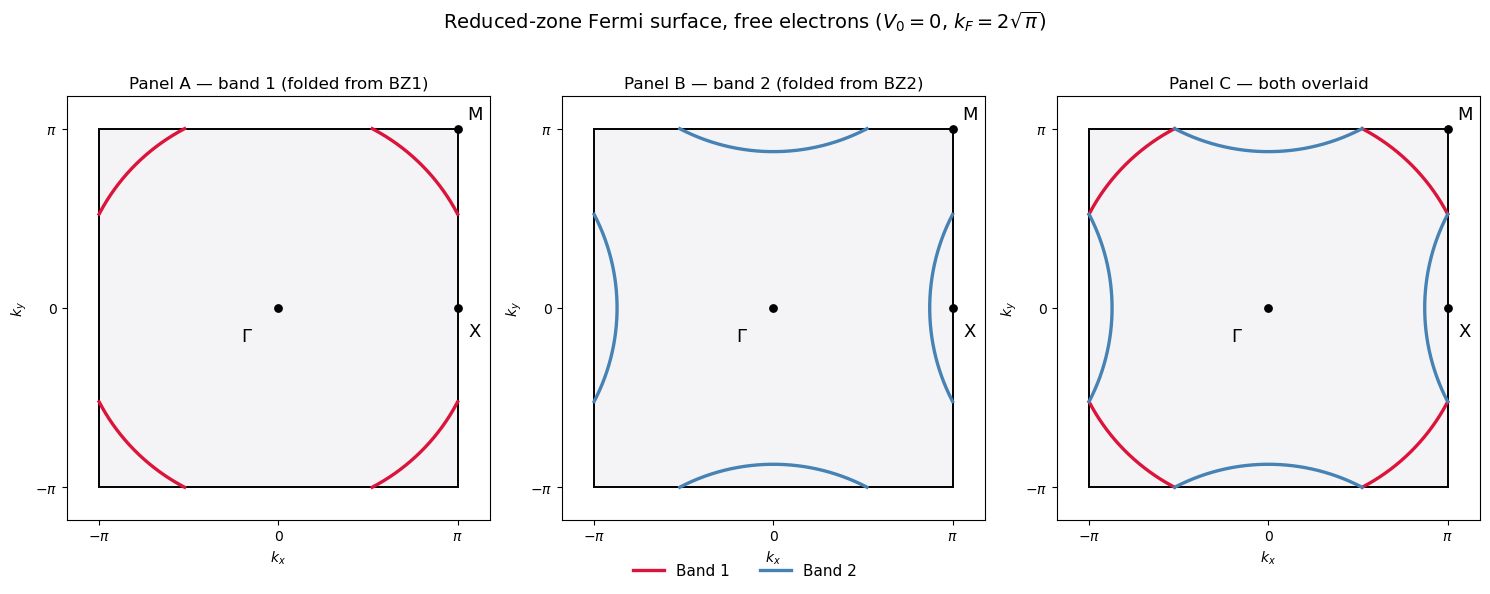

In [ ]:
BAND1_COLOR = "crimson"
BAND2_COLOR = "steelblue"
BZ_EDGE = "black"
BZ_FILL = "#f4f4f6"

def draw_bz_frame(ax):
    """Draw the BZ1 square, Gamma/X/M markers and labels on a panel."""
    pi = np.pi
    ax.add_patch(Rectangle((-pi, -pi), 2 * pi, 2 * pi,
                           facecolor=BZ_FILL, edgecolor=BZ_EDGE,
                           linewidth=1.4, zorder=1))

    hs = high_symmetry_points()
    display_names = {"Gamma": r"$\Gamma$", "X": "X", "M": "M"}
    label_offsets = {"Gamma": (-0.55, -0.5), "X": (0.30, -0.4), "M": (0.30, 0.25)}
    for name, k in hs.items():
        ax.scatter(*k, color="black", s=28, zorder=5)
        dx, dy = label_offsets[name]
        ax.annotate(display_names[name], xy=k, xytext=(k[0] + dx, k[1] + dy),
                    fontsize=13, color="black", zorder=6,
                    ha="center", va="center")

    LIM = 1.18 * pi
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal")
    ax.set_xticks([-pi, 0, pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-pi, 0, pi]); ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")


fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.6))

# Panel A: band 1 only.
ax = axes[0]
draw_bz_frame(ax)
for arc in band1_arcs:
    ax.plot(arc[:, 0], arc[:, 1], color=BAND1_COLOR, linewidth=2.4, zorder=3)
ax.set_title("Panel A — band 1 (folded from BZ1)", fontsize=12)

# Panel B: band 2 only.
ax = axes[1]
draw_bz_frame(ax)
for arc in band2_arcs:
    ax.plot(arc[:, 0], arc[:, 1], color=BAND2_COLOR, linewidth=2.4, zorder=3)
ax.set_title("Panel B — band 2 (folded from BZ2)", fontsize=12)

# Panel C: both overlaid.
ax = axes[2]
draw_bz_frame(ax)
for arc in band1_arcs:
    ax.plot(arc[:, 0], arc[:, 1], color=BAND1_COLOR, linewidth=2.4, zorder=3)
for arc in band2_arcs:
    ax.plot(arc[:, 0], arc[:, 1], color=BAND2_COLOR, linewidth=2.4, zorder=3)
ax.set_title("Panel C — both overlaid", fontsize=12)

# Figure-level legend below the panels — keeps each BZ1 frame clean.
band1_proxy = plt.Line2D([0], [0], color=BAND1_COLOR, linewidth=2.4, label="Band 1")
band2_proxy = plt.Line2D([0], [0], color=BAND2_COLOR, linewidth=2.4, label="Band 2")
fig.legend(handles=[band1_proxy, band2_proxy],
           loc="lower center", ncol=2, fontsize=11, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(r"Reduced-zone Fermi surface, free electrons ($V_0 = 0$, $k_F = 2\sqrt{\pi}$)",
             fontsize=14, y=1.02)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIG_DIR / "figure_05_reduced_zone_fermi_surface.png", dpi=180, bbox_inches="tight")
plt.show()